In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression # Linear Regression Model
from sklearn.preprocessing import StandardScaler #Z-score variables

In `scikit-learn`, a simple feedforward neural network is called an **MLP**:

- `MLPClassifier` for classification
- `MLPRegressor` for regression

MLP stands for **multilayer perceptron**.

We will start with a dataset that is not too complicated.

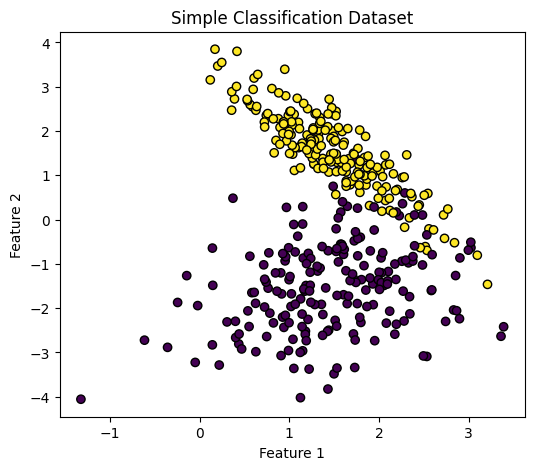

In [2]:
X, y = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Simple Classification Dataset")
plt.show()

### Quick check
1. How many input features does each data point have?
2. Is this a classification or regression problem?
3. Why might logistic regression work reasonably well here?

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (300, 2)
Test set shape: (100, 2)


Recall: logistic regression can be viewed as a very simple neural network with no hidden layer.

In [4]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

log_acc = accuracy_score(y_test, y_pred_log)
print("Logistic Regression accuracy:", round(log_acc, 3))

Logistic Regression accuracy: 0.95


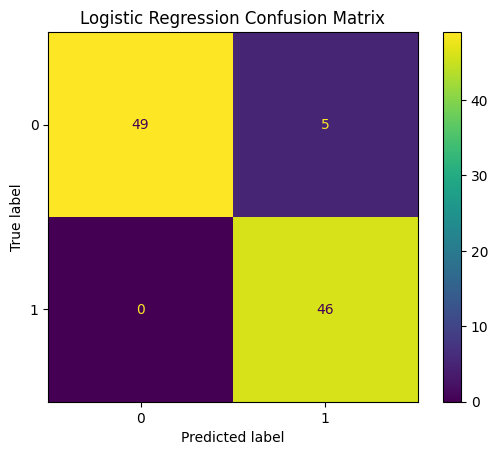

In [5]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Train a neural network with scikit-learn

Now we use `MLPClassifier`.

The argument `hidden_layer_sizes=(5,)` means:
- 1 hidden layer
- 5 neurons in that hidden layer

In [6]:
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(5,),
        max_iter=2000,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
print("MLPClassifier accuracy:", round(mlp_acc, 3))

MLPClassifier accuracy: 0.94


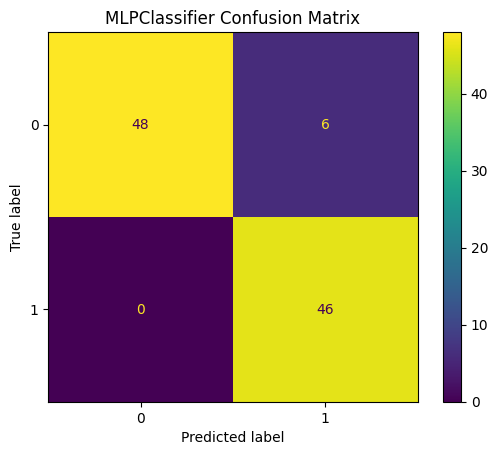

In [7]:
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("MLPClassifier Confusion Matrix")
plt.show()

### Student activity 2
Compare logistic regression and the neural network.

1. Which model had higher accuracy?
2. Were the results very different on this dataset?
3. Why might the difference be small here?

In [8]:
mlp_inner = mlp_model.named_steps["model"]

print("Hidden layer sizes:", mlp_inner.hidden_layer_sizes)
print("Activation:", mlp_inner.activation)
print("Solver:", mlp_inner.solver)
print("Number of iterations:", mlp_inner.n_iter_)

Hidden layer sizes: (5,)
Activation: relu
Solver: adam
Number of iterations: 657


### Task
Change the hidden layer size and rerun the model.

Try these one at a time:
- `(2,)`
- `(10,)`
- `(20, 10)`

After each run, record:
- test accuracy
- number of iterations
- whether performance improved a lot, a little, or not at all

In [10]:
# Try your own hidden layer size here
mlp_try = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(20,10),
        max_iter=2000,
        random_state=42
    ))
])

mlp_try.fit(X_train, y_train)
y_pred_try = mlp_try.predict(X_test)

print("New accuracy:", round(accuracy_score(y_test, y_pred_try), 3))

New accuracy: 0.95


##  A harder dataset: nonlinear pattern

Now let us use a dataset shaped like two moons.

This is useful because it is **not linearly separable**.

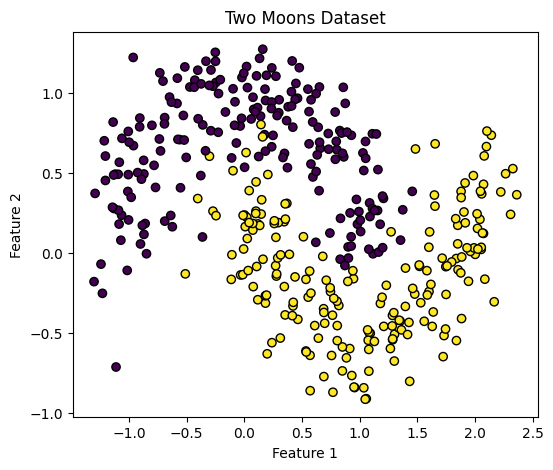

In [11]:
X2, y2 = make_moons(n_samples=400, noise=0.2, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=y2, edgecolor="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two Moons Dataset")
plt.show()

In [12]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42
)

##  Logistic regression on the nonlinear dataset

In [13]:
log_model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

log_model2.fit(X2_train, y2_train)
y2_pred_log = log_model2.predict(X2_test)

print("Logistic Regression accuracy on moons:", round(accuracy_score(y2_test, y2_pred_log), 3))

Logistic Regression accuracy on moons: 0.79


## Neural network on the nonlinear dataset

In [14]:
mlp_model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(10, 10),
        max_iter=3000,
        random_state=42
    ))
])

mlp_model2.fit(X2_train, y2_train)
y2_pred_mlp = mlp_model2.predict(X2_test)

print("MLPClassifier accuracy on moons:", round(accuracy_score(y2_test, y2_pred_mlp), 3))

MLPClassifier accuracy on moons: 0.96


### Compare the two models on the moons dataset.

1. Which model performed better now?
2. Why is this dataset harder for logistic regression?


### Use Tensorflow


In [17]:
import tensorflow as tf
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/Music_data.csv")
feats = ["danceability", "energy", "loudness","acousticness"]
predict = "valence"

print(df.shape)
X = df[feats]
y = df[predict]

z = StandardScaler()

X = z.fit_transform(X)

(2553, 14)


the model below has the same shape as a simple linear regression, like we talked about in lecture. It has an input layer with 4 inputs ("danceability", "energy", "loudness","acousticness"), and 1 output layer for "valence".

<img src="https://drive.google.com/uc?export=view&id=16JR3yX1gs7oC1isJAaJixNkrnZmdOxn1" width = 800px />

In [20]:
#structure of the model
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape =[4]), #input
])

#how to train the model
model1.compile(loss = "mean_squared_error",
              optimizer = tf.keras.optimizers.SGD())

#fit the model (same as SKlearn)
model1.fit(X,y, epochs = 5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8218
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0955
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0523
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0410
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0374


In [19]:
# get weights from Neural Network
model1.get_weights()

[array([[ 0.08329178],
        [-0.08064658],
        [ 0.10273288],
        [-0.01902799]], dtype=float32),
 array([0.47268072], dtype=float32)]

In [ ]:
# build a linear regression model using LinearRegression and fitting on X and y (no need for model validation here)

### YOUR CODE HERE ###


In [ ]:
# get the coef_ and intercept_ from your linear regression model

### YOUR CODE HERE ###

### *Question*
What happens to the weights from our neural net as you **increase** the number of epochs (compare to the coefs from the linear regression model)?

<img src="https://drive.google.com/uc?export=view&id=1ghyQPx1N8dmU3MV4TrANvqNhGwnLni72" width = 200px />

In [ ]:
## DEEP MODEL
#structure of the model
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(7, input_shape =[4]), #input
    tf.keras.layers.Dense(???),
    tf.keras.layers.Dense(???),
    tf.keras..layers.Dense(???) #output
])
#how to train the model
model2.compile(loss = "mean_squared_error",
              optimizer = tf.keras.optimizers.SGD())

#fit the model (same as SKlearn)
model2.fit(X,y, epochs = 100)

In [ ]:
### compare the performance of model1 and model2
### Your code here###